# Flare de AU Mic no SPARC4 — dados brutos, quatro bandas

O fluxo medido em função do tempo, **sem rebinar, sem suavizar e sem ajustar
quiescente**: a fotometria de abertura sai do produto `*_lc.fits` do pipeline
na cadência nativa de cada canal e é usada como está.

| célula | o que faz |
|:--:|---|
| 1 | configuração e leitura crua dos quatro canais |
| 2 | **corta o tempo exato da flare e guarda nos vetores** |
| 3 | gráfico: fluxo cru de cada banda em função do tempo |
| 4 | a noite bruta inteira, sem cortar nada |

A única conta feita sobre os números do pipeline é a razão
**alvo / Σcomparações** — uma divisão ponto a ponto, que tira extinção e
transparência sem tocar na amostragem. A cadência não é a mesma nos quatro
canais (4.1 s no `g`, 1.3 s em `r`/`i`/`z`), então os vetores de cada banda têm
**tamanhos diferentes**; interpolar para uma grade comum já seria mexer nos
dados, e é justamente o que este notebook não faz.

Consequência de olhar o dado cru: a amplitude lida no ponto de máximo é maior
que a da curva binada — ≈209 000 ppm contra 182 000 ppm em `g` — porque um ponto
isolado carrega o ruído inteiro. Para medir amplitude, temperatura e energia,
use o notebook `sparc4_flares_aumic.ipynb`; este aqui é para **ver** o dado.

In [6]:
# ═══ leitura crua dos LC do SPARC4 ─ só abre o que existe e cataloga ════════
import glob
import os
import re

import numpy as np
from astropy.io import fits
from astropy.time import Time

BASE   = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
BANDAS = {1: "g", 2: "r", 3: "i", 4: "z"}

arquivos = sorted(glob.glob(os.path.join(BASE, "**", "*_lc.fits"), recursive=True))


def le_lc(arq):
    """Lê um arquivo _lc.fits inteiro: todas as extensões, todas as colunas.

    Nada é filtrado, ordenado ou combinado — as colunas saem como o pipeline
    gravou. Cada extensão vira uma entrada em `aper`, indexada pelo APRADIUS
    do header (ou pelo número da extensão, se o header não trouxer o campo).
    """
    nome = os.path.basename(arq)
    ch   = re.search(r"_s4c(\d)_", nome)
    feix = re.search(r"_(S\+N|S-N|S|N)_lc\.fits$", nome)

    reg = dict(arquivo=nome, caminho=arq, noite=os.path.basename(os.path.dirname(arq)),
               canal=int(ch.group(1)) if ch else None,
               banda=BANDAS.get(int(ch.group(1))) if ch else None,
               feixe=feix.group(1) if feix else None, aper={})

    with fits.open(arq) as h:
        reg["header"] = dict(h[0].header)
        for i, ext in enumerate(h[1:], start=1):
            d = ext.data
            if d is None:
                continue
            cols = {c: np.asarray(d[c]) for c in d.columns.names}
            r = ext.header.get("APRADIUS", i)
            t = np.unique(np.asarray(cols["TIME"], float)) if "TIME" in cols else np.array([])
            reg["aper"][r] = dict(ext=i, colunas=list(cols), n_linhas=len(d), dados=cols,
                                  t=t, n_fontes=np.unique(cols["SRCINDEX"]).size if "SRCINDEX" in cols else 0,
                                  cad=float(np.median(np.diff(t)) * 86400) if t.size > 1 else np.nan)
    return reg


lc = {}
for arq in arquivos:
    r = le_lc(arq)
    lc[(r["noite"], r["banda"], r["feixe"])] = r

print(f"{len(arquivos)} arquivo(s) em {BASE}")
print()
print(f"{'noite':>10} {'banda':>6} {'feixe':>6} {'aper':>5} {'fontes':>7} "
      f"{'pontos':>7} {'cadencia':>10} {'inicio UTC':>11} {'fim UTC':>9}")
for (noite, banda, feixe), r in sorted(lc.items()):
    for a in sorted(r["aper"]):
        e = r["aper"][a]
        if e["t"].size:
            ini = Time(e["t"][0],  format="jd", scale="utc").iso[11:19]
            fim = Time(e["t"][-1], format="jd", scale="utc").iso[11:19]
        else:
            ini = fim = "-"
        print(f"{noite:>10} {str(banda):>6} {str(feixe):>6} {str(a):>5} {e['n_fontes']:>7} "
              f"{e['t'].size:>7} {e['cad']:>9.2f}s {ini:>11} {fim:>9}")

if lc:
    k = sorted(lc)[0]
    a = sorted(lc[k]["aper"])[0]
    print()
    print("colunas disponiveis:", lc[k]["aper"][a]["colunas"])

79 arquivo(s) em C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data

     noite  banda  feixe  aper  fontes  pontos   cadencia  inicio UTC   fim UTC
  20260702      g    S+N     5      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N     8      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    10      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    12      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    15      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    20      21    8475      2.52s    01:41:02  08:39:32
  20260702      g    S+N    25      21    8475      2.52s    01:41:02  08:39:32
  20260702      i    S+N     5      17   16952      1.27s    01:41:02  08:39:34
  20260702      i    S+N     8      17   16952      1.27s    01:41:02  08:39:34
  20260702      i    S+N    10      17   16952      1.27s    01:41:02  08:39:34
  20260702      i    S+

In [11]:
# ═══ 1 · configuração e leitura CRUA dos produtos do pipeline ═══════════════
# Nada aqui é rebinado, suavizado ou normalizado: o que sai é a fotometria de
# abertura como o pipeline gravou, na cadência nativa de cada canal (em
# 2026-08-15: 4.1 s no g e 1.3 s em r/i/z, grades diferentes entre si).
import glob
import os

import numpy as np
from astropy.io import fits
from astropy.time import Time

BASE    = r"C:/Users/paola/Desktop/Doutorado/Codigos-doc/Flares-/novo_homepage/Sparc4-data"
DATADIR = os.path.join(BASE, "data")
OUTDIR  = os.path.join(BASE, "resultados_flares")

NOITE  = "20260815"
BEAM   = "S+N"     # soma dos dois feixes: cancela a modulação da lâmina
APER   = 8         # raio da abertura, em pixels
NCOMPS = 3         # nº de comparações: as mais brilhantes depois do alvo

BANDAS = {1: "g", 2: "r", 3: "i", 4: "z"}
CORES  = {"g": "#3b6ea5", "r": "#3f8f4f", "i": "#c06a2a", "z": "#8b3a5a"}
LAMBDA = {"g": 457, "r": 614, "i": 753, "z": 894}      # nm, efetivo


def le_bruto(ch, noite=NOITE, aper=APER, ncomps=NCOMPS):
    """Fotometria crua de um canal: alvo, comparações e razão, ponto a ponto.

    O alvo é a fonte mais brilhante do campo e as comparações são as `ncomps`
    seguintes. A razão alvo/Σcomparações é a única conta feita — uma divisão,
    que tira extinção e transparência sem tocar na amostragem. Nenhum ponto é
    descartado por ser outlier: a flare é, por definição, um outlier positivo.
    Só viram NaN os pontos que o próprio pipeline marcou com FLAG.
    """
    padrao = os.path.join(DATADIR, noite, f"*_s4c{ch}_*_{BEAM}_lc.fits")
    arq = sorted(glob.glob(padrao))[0]

    with fits.open(arq) as h:
        ext = [e for e in h[1:] if e.header.get("APRADIUS") == aper][0]
        d = ext.data
        src  = np.asarray(d["SRCINDEX"], float).astype(int)
        t    = np.asarray(d["TIME"], float)          # BJD_UTC
        mag  = np.asarray(d["MAG"], float)
        emag = np.asarray(d["EMAG"], float)
        flag = np.asarray(d["FLAG"])

    # (fonte, instante) -> matriz
    idx, t_jd = np.unique(src), np.unique(t)
    lin, col = np.searchsorted(idx, src), np.searchsorted(t_jd, t)
    M = np.full((idx.size, t_jd.size), np.nan)
    E = np.full_like(M, np.nan)
    M[lin, col], E[lin, col] = mag, emag
    ruim = np.zeros(M.shape, bool)
    ruim[lin, col] = np.asarray(flag) != 0
    M[ruim] = np.nan

    ordem = np.argsort(np.nanmedian(M, axis=1))      # do mais brilhante
    ia, ic = ordem[0], ordem[1:1 + ncomps]

    with np.errstate(invalid="ignore", divide="ignore"):
        f_alvo = 10 ** (-0.4 * M[ia])
        f_comp = np.nansum(10 ** (-0.4 * M[ic]), axis=0)
        e_comp = np.sqrt(np.nansum((10 ** (-0.4 * M[ic]) * E[ic]) ** 2, axis=0))
        razao  = f_alvo / f_comp
        e_raz  = razao * 0.4 * np.log(10) * np.hypot(
            E[ia], e_comp / np.where(f_comp > 0, f_comp, np.nan))

    return dict(banda=BANDAS[ch], canal=ch, arquivo=os.path.basename(arq),
                alvo=int(idx[ia]), comps=[int(idx[c]) for c in ic],
                t=t_jd, f_alvo=f_alvo, f_comp=f_comp, razao=razao, sig=e_raz,
                cad=float(np.median(np.diff(t_jd)) * 86400))


bruto = {BANDAS[ch]: le_bruto(ch) for ch in BANDAS}

print(f"noite {NOITE[:4]}-{NOITE[4:6]}-{NOITE[6:]} - feixe {BEAM} - abertura {APER} px")
print()
print(f"{'banda':>6} {'pontos':>8} {'cadencia':>10} {'inicio UTC':>12} {'fim UTC':>10}")
for b, d in bruto.items():
    ini = Time(d["t"][0],  format="jd", scale="utc").iso[11:19]
    fim = Time(d["t"][-1], format="jd", scale="utc").iso[11:19]
    print(f"{b:>6} {d['t'].size:>8} {d['cad']:>9.2f}s {ini:>12} {fim:>10}")

noite 2026-08-15 - feixe S+N - abertura 8 px

 banda   pontos   cadencia   inicio UTC    fim UTC
     g     1938      4.12s     22:34:10   01:16:09
     r     6524      1.32s     22:34:09   01:16:13
     i     6524      1.32s     22:34:09   01:16:13
     z     6524      1.32s     22:34:09   01:16:13


flare F01 - inicio 2026-08-15 22:38:10 TDB = 22:37:00 UTC
duracao 17 min + 2 min de margem de cada lado
janela: 22:35:00 a 22:56:00 UTC

 banda   pontos    t pico        amp   S/R pico
                    [min]      [ppm]
     g      262      1.15     208615       49.6
     r      872      1.98     114439       18.3
     i      872      1.98      71248        8.9
     z      872      1.95      73282        7.1


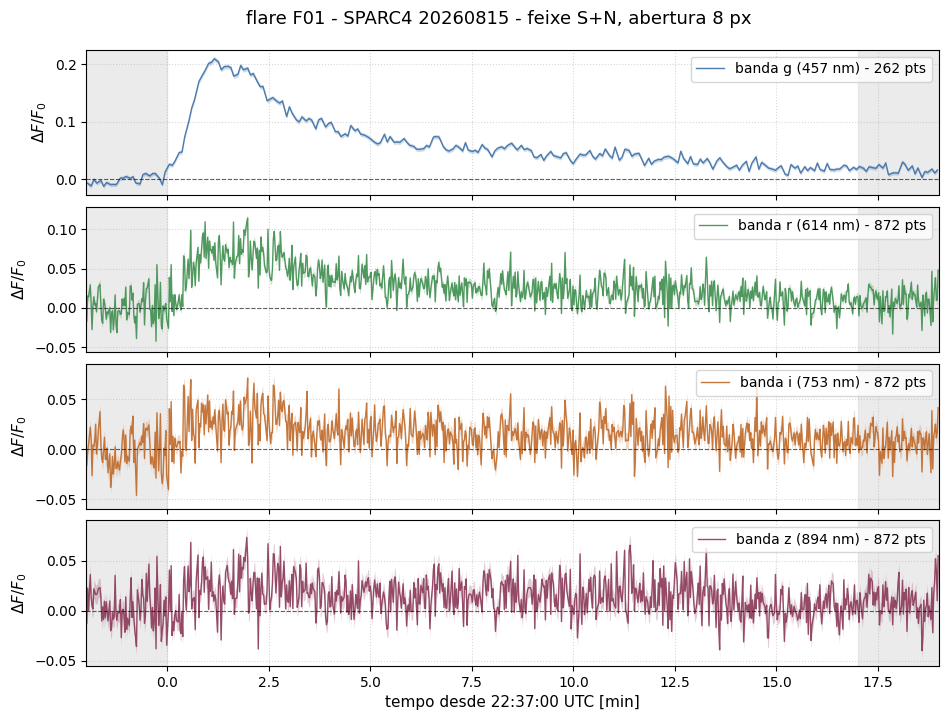

In [13]:
# ═══ 2 · corta a janela da flare e plota ΔF/F₀ nas quatro bandas ════════════
# A janela vem do horário medido da flare (tabela do notebook principal):
# início 22:38:10, 17 min de duração. PAD_MIN acrescenta uma margem de
# quiescente de cada lado — é ela que dá a referência de fluxo fora da flare.
# Cada banda é cortada na SUA grade, sem interpolar para uma grade comum: os
# vetores saem com tamanhos diferentes, e é assim que tem de ser.
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time
from scipy.stats import sigmaclip

FLARE   = "F01"
INICIO  = "2026-08-15 22:38:10"   # como sai na tabela do notebook principal
ESCALA  = "tdb"                   # ...e essa tabela imprime BJD_TDB, não UTC:
                                  # são 69 s de diferença, mais de um bin. A
                                  # coluna TIME do FITS é BJD_UTC, então o
                                  # horário tem de ser convertido antes do corte.
DUR_MIN = 17                      # duração medida, em minutos
PAD_MIN = 2.0                     # margem de quiescente de cada lado

t0 = Time(INICIO, format="iso", scale=ESCALA).utc.jd   # t = 0 dos vetores
INICIO_UTC = Time(t0, format="jd", scale="utc").iso[11:19]
ja = t0 - PAD_MIN / 1440.0
jb = t0 + (DUR_MIN + PAD_MIN) / 1440.0

flare = {}
for b, d in bruto.items():
    m = (d["t"] >= ja) & (d["t"] <= jb) & np.isfinite(d["razao"])
    t_min = (d["t"][m] - t0) * 1440.0                  # min desde o início
    pre   = d["razao"][m][t_min < 0]
    # nível de repouso: mediana do pré-flare; se a margem não pegou nenhum
    # ponto, cai para sigma-clip assimétrico (corta só o pico positivo).
    base  = float(np.median(pre)) if pre.size else float(
        np.median(sigmaclip(d["razao"][m], low=3.0, high=2.0)[0]))
    flare[b] = dict(
        t_jd   = d["t"][m],          # BJD_UTC, cru
        t_min  = t_min,              # minutos desde o inicio da flare
        razao  = d["razao"][m],      # alvo / soma das comparacoes, cru
        sig    = d["sig"][m],        # erro propagado da fotometria
        f_alvo = d["f_alvo"][m],     # fluxo do alvo, cru
        f_comp = d["f_comp"][m],     # soma das comparacoes, cru
        base   = base,               # nivel pre-flare (referencia, nao aplicado)
        dff    = d["razao"][m] / base - 1.0,   # ΔF/F0, só para o gráfico
        edff   = d["sig"][m] / base,
    )

print(f"flare {FLARE} - inicio {INICIO} {ESCALA.upper()} = {INICIO_UTC} UTC")
print(f"duracao {DUR_MIN:.0f} min + {PAD_MIN:.0f} min de margem de cada lado")
print(f"janela: {Time(ja, format='jd', scale='utc').iso[11:19]} a "
      f"{Time(jb, format='jd', scale='utc').iso[11:19]} UTC")
print()
print(f"{'banda':>6} {'pontos':>8} {'t pico':>9} {'amp':>10} {'S/R pico':>10}")
print(f"{'':>6} {'':>8} {'[min]':>9} {'[ppm]':>10}")
for b, v in flare.items():
    k   = int(np.argmax(v["razao"]))
    amp = (v["razao"][k] / v["base"] - 1.0) * 1e6      # ppm = partes por milhão
    print(f"{b:>6} {v['t_min'].size:>8} {v['t_min'][k]:>9.2f} {amp:>10.0f} "
          f"{(v['razao'][k] - v['base']) / v['sig'][k]:>10.1f}")

# os vetores de cada banda, prontos para usar adiante:
t_g, C_g = flare["g"]["t_min"], flare["g"]["razao"]
t_r, C_r = flare["r"]["t_min"], flare["r"]["razao"]
t_i, C_i = flare["i"]["t_min"], flare["i"]["razao"]
t_z, C_z = flare["z"]["t_min"], flare["z"]["razao"]

# ── gráfico: 4 painéis empilhados, eixo x comum, cada banda na sua grade ────
fig, axes = plt.subplots(4, 1, figsize=(11, 8), sharex=True,
                         gridspec_kw={"hspace": 0.08})

for ax, b in zip(axes, ["g", "r", "i", "z"]):
    v, cor = flare[b], CORES.get(b, "#333333")
    ax.plot(v["t_min"], v["dff"], color=cor, lw=1.0, alpha=0.9,
            label=f"banda {b} ({LAMBDA[b]} nm) - {v['t_min'].size} pts")
    ax.fill_between(v["t_min"], v["dff"] - v["edff"], v["dff"] + v["edff"],
                    color=cor, alpha=0.25, linewidth=0)
    ax.axhline(0, color="black", ls="--", lw=0.8, alpha=0.6)
    ax.axvspan(-PAD_MIN, 0, color="0.85", alpha=0.5, zorder=0)          # pré-flare
    ax.axvspan(DUR_MIN, DUR_MIN + PAD_MIN, color="0.85", alpha=0.5, zorder=0)
    ax.set_ylabel(r"$\Delta F / F_0$", fontsize=11)
    ax.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.8)
    ax.grid(True, ls=":", alpha=0.5)

axes[-1].set_xlabel(f"tempo desde {INICIO_UTC} UTC [min]", fontsize=11)
axes[-1].set_xlim(-PAD_MIN, DUR_MIN + PAD_MIN)
fig.suptitle(f"flare {FLARE} - SPARC4 {NOITE} - feixe {BEAM}, abertura {APER} px",
             fontsize=13, y=0.93)
plt.show()

In [14]:
import numpy as np, pandas as pd
from scipy.integrate import trapezoid
from PyAstronomy.pyasl import planck
from scipy.integrate import simpson


tf   = pd.read_csv("data/sparc4_spectral_response.csv")
nm   = np.array(tf["Wavelength (nm)"])
ry_g = np.array(tf["Channel g (%)"])/100
ry_r = np.array(tf["Channel r (%)"])/100
ry_i = np.array(tf["Channel i (%)"])/100
ry_z = np.array(tf["Channel z (%)"])/100

Teff, Tflare = 3700, 10000
raio     = 0.75*6.968e+8
Aestrela = np.pi*raio**2
sb1      = 5.670374e-8
n        = 264

# limites por canal (onde a resposta é não-nula)
lambda_min_g, lambda_max_g = nm[ry_g>0].min(), nm[ry_g>0].max()   # 350.0 - 683.3 nm
lambda_min_r, lambda_max_r = nm[ry_r>0].min(), nm[ry_r>0].max()   # 448.5 - 1084.8 nm
lambda_min_i, lambda_max_i = nm[ry_i>0].min(), nm[ry_i>0].max()   # 456.1 - 1100.0 nm
lambda_min_z, lambda_max_z = nm[ry_z>0].min(), nm[ry_z>0].max()   # 539.4 - 1100.0 nm

# grade própria de cada canal
wv_g = np.linspace(lambda_min_g, lambda_max_g, n)
wv_r = np.linspace(lambda_min_r, lambda_max_r, n)
wv_i = np.linspace(lambda_min_i, lambda_max_i, n)
wv_z = np.linspace(lambda_min_z, lambda_max_z, n)

# resposta reamostrada na grade do próprio canal
R_g = np.interp(wv_g, nm, ry_g)
R_r = np.interp(wv_r, nm, ry_r)
R_i = np.interp(wv_i, nm, ry_i)
R_z = np.interp(wv_z, nm, ry_z)

# Planck da estrela e da flare, canal a canal
Bs_g, Bf_g = planck(Teff, lam=wv_g*1.e-9), planck(Tflare, lam=wv_g*1.e-9)
Bs_r, Bf_r = planck(Teff, lam=wv_r*1.e-9), planck(Tflare, lam=wv_r*1.e-9)
Bs_i, Bf_i = planck(Teff, lam=wv_i*1.e-9), planck(Tflare, lam=wv_i*1.e-9)
Bs_z, Bf_z = planck(Teff, lam=wv_z*1.e-9), planck(Tflare, lam=wv_z*1.e-9)



In [15]:
# os vetores de cada banda, prontos para usar adiante:
t_g, C_g = flare["g"]["t_min"], flare["g"]["razao"]
t_r, C_r = flare["r"]["t_min"], flare["r"]["razao"]
t_i, C_i = flare["i"]["t_min"], flare["i"]["razao"]
t_z, C_z = flare["z"]["t_min"], flare["z"]["razao"]

Amplitude da flare (DeltaF/F) por banda:
g: 0.201469


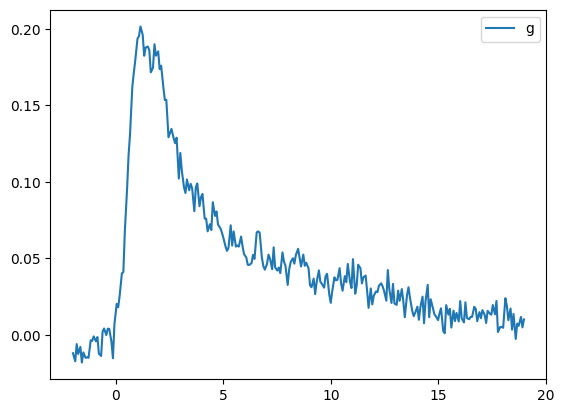

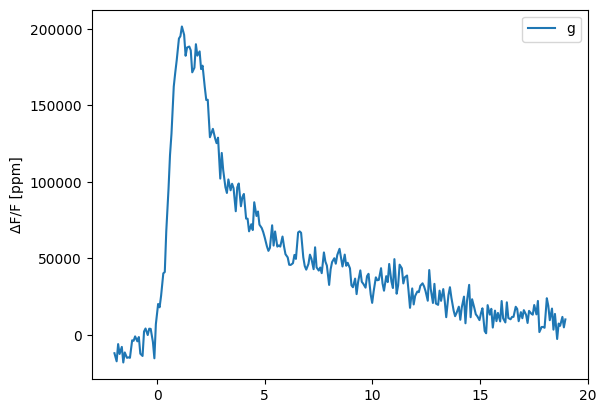

g: 201469 ppm


In [16]:
### Amplitude da flare (DeltaF/F) por banda

import numpy as np

def amplitude(t, C, fora):          # fora = máscara do trecho quiescente (sem flare)
    base = np.median(C[fora])
    return (C - base)/base

fora = t_g < t_g[np.argmax(C_g)] - 0.02      # ajuste o 0.02 (em dias) à sua flare
a_g  = amplitude(t_g, C_g, fora)

amps = np.column_stack([a_g])       # (N, 1) por enquanto

print("Amplitude da flare (DeltaF/F) por banda:")
print(f"g: {np.max(a_g):.6f}")

plt.plot(t_g, a_g, label="g")
plt.legend(); plt.show()

a_g_ppm = a_g * 1e6

plt.plot(t_g, a_g_ppm, label="g")
plt.ylabel("ΔF/F [ppm]")
plt.legend(); plt.show()

print(f"g: {np.max(a_g_ppm):.0f} ppm")

In [18]:
c_max_g =np.max(a_g)          # fluxo normalizado no pico (não a amplitude)
area = (c_max_g - 1)*Aestrela*(simpson(Bs_g*R_g, wv_g) / simpson((Bf_g - Bs_g)*R_g, wv_g))
print(f"Área da flare (g): {area:.3e} m^2")

Área da flare (g): -3.079e+15 m^2


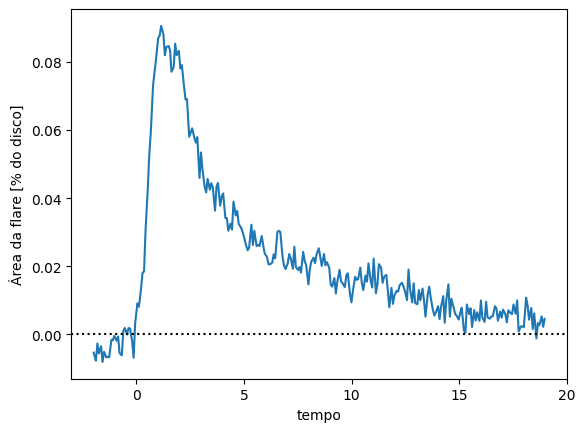

A_estrela   = 8.580e+17 m^2
A_flare pico= 7.769e+14 m^2
fração pico = 0.0906% do disco


In [19]:
### Área da flare no tempo + teste de sanidade

# area_t : array (N,) com a área calculada em cada instante  (mesma fórmula, usando a_g[i] no lugar de max)
area_t = a_g * Aestrela * (simpson(Bs_g*R_g, wv_g) / simpson((Bf_g - Bs_g)*R_g, wv_g))

frac = area_t / Aestrela                    # fração do disco estelar

plt.plot(t_g, frac*100)
plt.axhline(0, ls=":", c="k")
plt.ylabel("Área da flare [% do disco]")
plt.xlabel("tempo")
plt.show()

print(f"A_estrela   = {Aestrela:.3e} m^2")
print(f"A_flare pico= {area_t.max():.3e} m^2")
print(f"fração pico = {frac.max():.4%} do disco")
assert 0 <= frac.max() < 1, "área maior que a estrela -> algo errado no ajuste"

In [20]:
Aestrela_disco = Aestrela  # Associa a área calculada (np.pi * raio**2)

In [21]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.integrate import simpson
from PyAstronomy.pyasl import planck

# --- DADOS DOS CANAIS ---
canais = ['g', 'r', 'i', 'z']
amps_obs = []
erros_obs = []

# Dicionários para guardar amplitudes e tempos no tempo
a_t = {}
base_val = {}

for k in canais:
    t_k = np.array(flare[k]["t_min"])
    C_k = np.array(flare[k]["razao"])
    
    # 1. Máscara para pegar o trecho fora da flare (fase quiescente)
    pico_idx = np.argmax(C_k)
    # Exemplo: pontos localizados mais de 30 min (0.021 dias ou 30 min em t_min) antes do pico
    # AJUSTE o valor de offset conforme a unidade da sua coluna t_min!
    dt_offset = 30.0  # Assumindo t_min em minutos (subtrai 30 minutos)
    fora = t_k < (t_k[pico_idx] - dt_offset)
    
    # Se a máscara der vazia, pega os primeiros 20% dos pontos da curva de luz
    if not np.any(fora):
        fora = np.zeros(len(t_k), dtype=bool)
        fora[:int(len(t_k)*0.2)] = True

    # 2. Linha de base (fluxo quiescente mediano) e desvio padrão
    base = np.median(C_k[fora])
    sigma_base = np.std(C_k[fora])
    base_val[k] = base

    # 3. Vetor de amplitude no tempo: ΔF/F = (C - base) / base
    a_k = (C_k - base) / base
    a_t[k] = a_k

    # 4. Amplitude de pico e seu erro associado
    amp_max = np.max(a_k)
    err_amp = sigma_base / base  # Propagação do ruído fotométrico quiescente
    
    amps_obs.append(amp_max)
    erros_obs.append(err_amp)

amps_obs = np.array(amps_obs)
erros_obs = np.array(erros_obs)

print("--- AMPLITUDES NO PICO MEDIDAS ---")
for k, amp, err in zip(canais, amps_obs, erros_obs):
    print(f"Canal {k}: {amp*1e6:.0f} ± {err*1e6:.0f} ppm (ΔF/F = {amp:.6f})")

--- AMPLITUDES NO PICO MEDIDAS ---
Canal g: 178833 ± 85616 ppm (ΔF/F = 0.178833)
Canal r: 86850 ± 37103 ppm (ΔF/F = 0.086850)
Canal i: 58445 ± 24129 ppm (ΔF/F = 0.058445)
Canal z: 61452 ± 22724 ppm (ΔF/F = 0.061452)


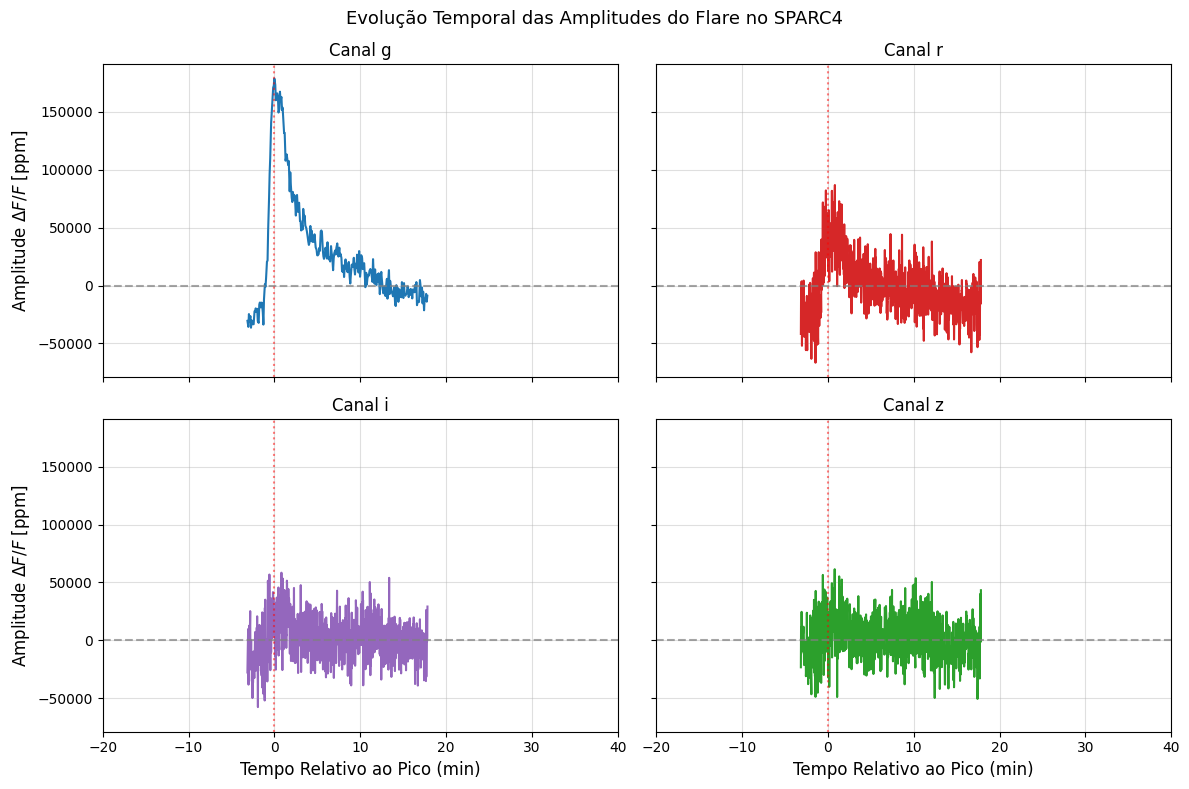

In [22]:
import matplotlib.pyplot as plt

cores = {
    'g': '#1f77b4',  # Azul
    'r': '#d62728',  # Vermelho
    'i': '#9467bd',  # Roxo
    'z': '#2ca02c'   # Verde
}

# Tempo do pico pelo canal g como referência
t_ref  = np.array(flare['g']["t_min"])
pico_t = t_ref[np.argmax(flare['g']["razao"])]

fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)

for ax, k in zip(axs.flat, canais):
    t_k     = np.array(flare[k]["t_min"]) - pico_t   # Tempo relativo ao pico (minutos)
    amp_ppm = a_t[k] * 1e6

    ax.plot(t_k, amp_ppm, color=cores[k], lw=1.5)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.7)
    ax.axvline(0, color='red', linestyle=':', alpha=0.5)
    ax.set_xlim(-20, 40)
    ax.set_title(f"Canal {k}", fontsize=12)
    ax.grid(True, alpha=0.4)

# rótulos comuns
for ax in axs[-1, :]:
    ax.set_xlabel("Tempo Relativo ao Pico (min)", fontsize=12)
for ax in axs[:, 0]:
    ax.set_ylabel(r"Amplitude $\Delta F / F$ [ppm]", fontsize=12)

fig.suptitle("Evolução Temporal das Amplitudes do Flare no SPARC4", fontsize=13)
plt.tight_layout()
plt.show()

In [23]:
# --- INTEGRAIS QUIESCENTES ESTELARES ---
I_star = np.array([
    simpson(Bs_g * R_g, wv_g),
    simpson(Bs_r * R_r, wv_r),
    simpson(Bs_i * R_i, wv_i),
    simpson(Bs_z * R_z, wv_z)
])

def modelo_amplitudes(params):
    T_flare, f_area = params  # f_area = A_flare / Aestrela_disco
    
    # Curvas de Planck da flare para a temperatura testada T_flare
    Bf_g = planck(T_flare, lam=wv_g * 1.e-9)
    Bf_r = planck(T_flare, lam=wv_r * 1.e-9)
    Bf_i = planck(T_flare, lam=wv_i * 1.e-9)
    Bf_z = planck(T_flare, lam=wv_z * 1.e-9)
    
    # Integrais do excesso do flare
    I_flare = np.array([
        simpson((Bf_g - Bs_g) * R_g, wv_g),
        simpson((Bf_r - Bs_r) * R_r, wv_r),
        simpson((Bf_i - Bs_i) * R_i, wv_i),
        simpson((Bf_z - Bs_z) * R_z, wv_z)
    ])
    
    # Modelo teórico: ΔF/F = f_area * (I_flare / I_star)
    return f_area * (I_flare / I_star)

def chi2(params):
    amp_teorica = modelo_amplitudes(params)
    return np.sum(((amps_obs - amp_teorica) / erros_obs)**2)

# Minimização
chute_inicial = [10000.0, 0.001] # 10000 K, 0.1% do disco
limites = [(Teff + 100.0, 50000.0), (1e-6, 0.1)]

res = minimize(chi2, chute_inicial, bounds=limites, method='L-BFGS-B')

T_real_max, f_area_real = res.x
A_flare_real = f_area_real * Aestrela_disco

print("\n--- RESULTADO DA TEMPERATURA REAL DA FLARE (MÉTODOS IIb) ---")
print(f"Temperatura Real no Pico (T_max): {T_real_max:.1f} K")
print(f"Área Real Fixa (A_flare):         {A_flare_real:.3e} m²")
print(f"Fração do Disco Estelar:          {f_area_real * 100:.4f}% ({f_area_real * 1e6:.0f} ppm)")


--- RESULTADO DA TEMPERATURA REAL DA FLARE (MÉTODOS IIb) ---
Temperatura Real no Pico (T_max): 10000.0 K
Área Real Fixa (A_flare):         1.067e+15 m²
Fração do Disco Estelar:          0.1243% (1243 ppm)


Temperatura Real de Pico:   8857.5 K
Temperatura Quiescente:      3700.0 K
Luminosidade de Pico:       3.722e+23 W (3.722e+30 erg/s)
ENERGIA BOLOMÉTRICA TOTAL:  9.926e+25 J (9.926e+32 erg)


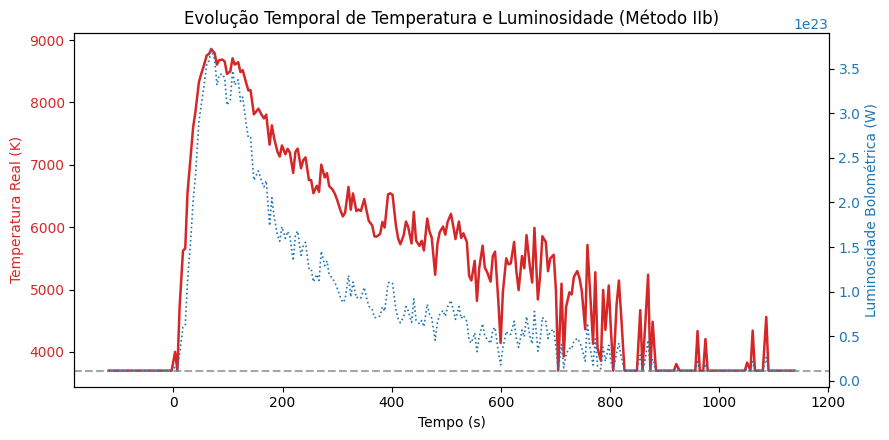

In [24]:
from scipy.optimize import root_scalar
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt


t_sec = np.array(flare["g"]["t_min"]) * 60.0  # Converte minutos -> segundos

# Lado direito fixo da Equação (7) para a estrela na banda g
I_star_g = simpson(Bs_g * R_g, wv_g)

# --- 2. SOLUÇÃO NUMÉRICA DA TEMPERATURA NO TEMPO T_flare(t) ---
T_flare_t = []

for amp in a_t['g']:
    # Para ruídos ou pontos fora do evento, a temperatura trava em Teff
    if amp <= 0:
        T_flare_t.append(Teff)
    else:
        # Lado direito da Equação (7) usando A_flare_real
        K_t = (1.0 + (amp * Aestrela_disco / A_flare_real)) * I_star_g
        
        # Função objetivo: busca T tal que Integral(Planck(T)*R) = K_t
        def objetivo(T):
            B_temp = planck(T, lam=wv_g * 1.e-9)
            return simpson(B_temp * R_g, wv_g) - K_t
        
        # Inversão numérica
        sol = root_scalar(objetivo, bracket=[Teff, 100000.0], method='brentq')
        T_flare_t.append(sol.root)

T_flare_t = np.array(T_flare_t)

# --- 3. LUMINOSIDADE E ENERGIA BOLOMÉTRICA TOTAL (Eq. 8 e Eq. 9) ---
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann em SI [W m^-2 K^-4]

# Luminosidade Bolométrica Instantânea em Watts (J/s)
L_flare_t = sb1 * (T_flare_t**4) * A_flare_real

# Integração temporal da energia em Joules e ergs
E_flare_J = trapezoid(L_flare_t, t_sec)
E_flare_erg = E_flare_J * 1.0e7

# --- 4. EXIBIÇÃO DOS RESULTADOS FINAIS ---
print("====================================================")
print(f"Temperatura Real de Pico:   {np.max(T_flare_t):.1f} K")
print(f"Temperatura Quiescente:      {np.min(T_flare_t):.1f} K")
print(f"Luminosidade de Pico:       {np.max(L_flare_t):.3e} W ({np.max(L_flare_t)*1e7:.3e} erg/s)")
print(f"ENERGIA BOLOMÉTRICA TOTAL:  {E_flare_J:.3e} J ({E_flare_erg:.3e} erg)")
print("====================================================")

# --- 5. GRÁFICO DA EVOLUÇÃO TEMPORAL ---
fig, ax1 = plt.subplots(figsize=(9, 4.5))

color = 'tab:red'
ax1.set_xlabel('Tempo (s)')
ax1.set_ylabel('Temperatura Real (K)', color=color)
ax1.plot(t_sec, T_flare_t, color=color, lw=1.8, label=r'$T_{\mathrm{flare}}(t)$ Real')
ax1.tick_params(axis='y', labelcolor=color)
ax1.axhline(Teff, color='gray', linestyle='--', alpha=0.7, label=f'Teff ({Teff} K)')

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Luminosidade Bolométrica (W)', color=color)
ax2.plot(t_sec, L_flare_t, color=color, lw=1.2, linestyle=':', label=r'$L_{\mathrm{flare}}(t)$')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("Evolução Temporal de Temperatura e Luminosidade (Método IIb)")
fig.tight_layout()
plt.show()

Canal   | T_pico (K)   | L_pico (W)      | Energia (erg)  
--------------------------------------------------------------------------
g       | 8857.5       | 3.722e+23       | 9.926e+32      
r       | 10543.5      | 7.473e+23       | 8.202e+32      
i       | 12299.0      | 1.384e+24       | 1.371e+33      
z       | 17120.6      | 5.196e+24       | 3.296e+33      


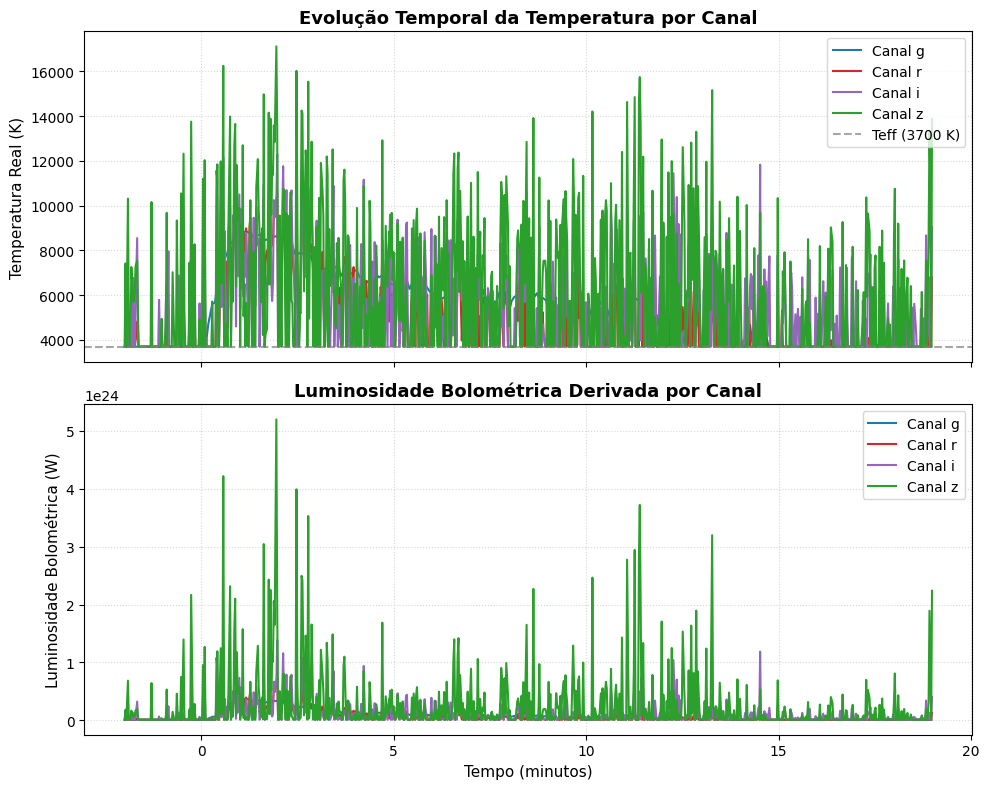

In [25]:
import numpy as np
from scipy.optimize import root_scalar
from scipy.integrate import simpson, trapezoid
import matplotlib.pyplot as plt

# --- 1. CONFIGURAÇÃO DOS CANAIS E ESTRUTURAS DE DADOS ---
canais = ['g', 'r', 'i', 'z']
sb1 = 5.670374e-8  # Constante de Stefan-Boltzmann [W m^-2 K^-4]

# Mapeamento dos vetores espectrais por canal
wv_dict = {'g': wv_g, 'r': wv_r, 'i': wv_i, 'z': wv_z}
R_dict  = {'g': R_g,  'r': R_r,  'i': R_i,  'z': R_z}
Bs_dict = {'g': Bs_g, 'r': Bs_r, 'i': Bs_i, 'z': Bs_z}

# Dicionários para armazenar os resultados por banda
T_flare_dict = {}
L_flare_dict = {}
E_flare_J_dict = {}
E_flare_erg_dict = {}
t_sec_dict = {}

# --- 2. CÁLCULO IDENTICO CANAL A CANAL ---
for k in canais:
    # Converter tempo de minutos para segundos
    t_sec = np.array(flare[k]["t_min"]) * 60.0
    t_sec_dict[k] = t_sec
    
    # Integral quiescente para o canal k
    I_star_k = simpson(Bs_dict[k] * R_dict[k], wv_dict[k])
    
    # Solução numérica da temperatura no tempo T_flare(t)
    T_k = []
    for amp in a_t[k]:
        if amp <= 0:
            T_k.append(Teff)
        else:
            K_t = (1.0 + (amp * Aestrela_disco / A_flare_real)) * I_star_k
            
            def objetivo(T):
                B_temp = planck(T, lam=wv_dict[k] * 1.e-9)
                return simpson(B_temp * R_dict[k], wv_dict[k]) - K_t
            
            sol = root_scalar(objetivo, bracket=[Teff, 100000.0], method='brentq')
            T_k.append(sol.root)
            
    T_k = np.array(T_k)
    T_flare_dict[k] = T_k
    
    # Luminosidade Bolométrica (W) e Energia (J e erg)
    L_k = sb1 * (T_k**4) * A_flare_real
    L_flare_dict[k] = L_k
    
    E_J = trapezoid(L_k, t_sec)
    E_erg = E_J * 1.0e7
    
    E_flare_J_dict[k] = E_J
    E_flare_erg_dict[k] = E_erg

# --- 3. EXIBIÇÃO DOS RESULTADOS COMPARATIVOS ---
print("==========================================================================")
print(f"{'Canal':<7} | {'T_pico (K)':<12} | {'L_pico (W)':<15} | {'Energia (erg)':<15}")
print("--------------------------------------------------------------------------")
for k in canais:
    T_max = np.max(T_flare_dict[k])
    L_max = np.max(L_flare_dict[k])
    E_erg = E_flare_erg_dict[k]
    print(f"{k:<7} | {T_max:<12.1f} | {L_max:<15.3e} | {E_erg:<15.3e}")
print("==========================================================================")

# --- 4. GRÁFICOS COMPARATIVOS MULTIBANDA ---
cores = {'g': '#1f77b4', 'r': '#d62728', 'i': '#9467bd', 'z': '#2ca02c'}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Painel 1: Temperatura
for k in canais:
    ax1.plot(t_sec_dict[k] / 60.0, T_flare_dict[k], label=f"Canal {k}", color=cores[k], lw=1.5)
ax1.axhline(Teff, color='gray', linestyle='--', alpha=0.7, label=f'Teff ({Teff} K)')
ax1.set_ylabel("Temperatura Real (K)", fontsize=11)
ax1.set_title("Evolução Temporal da Temperatura por Canal", fontsize=13, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle=':', alpha=0.5)

# Painel 2: Luminosidade Bolométrica
for k in canais:
    ax2.plot(t_sec_dict[k] / 60.0, L_flare_dict[k], label=f"Canal {k}", color=cores[k], lw=1.5)
ax2.set_xlabel("Tempo (minutos)", fontsize=11)
ax2.set_ylabel("Luminosidade Bolométrica (W)", fontsize=11)
ax2.set_title("Luminosidade Bolométrica Derivada por Canal", fontsize=13, fontweight='bold')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

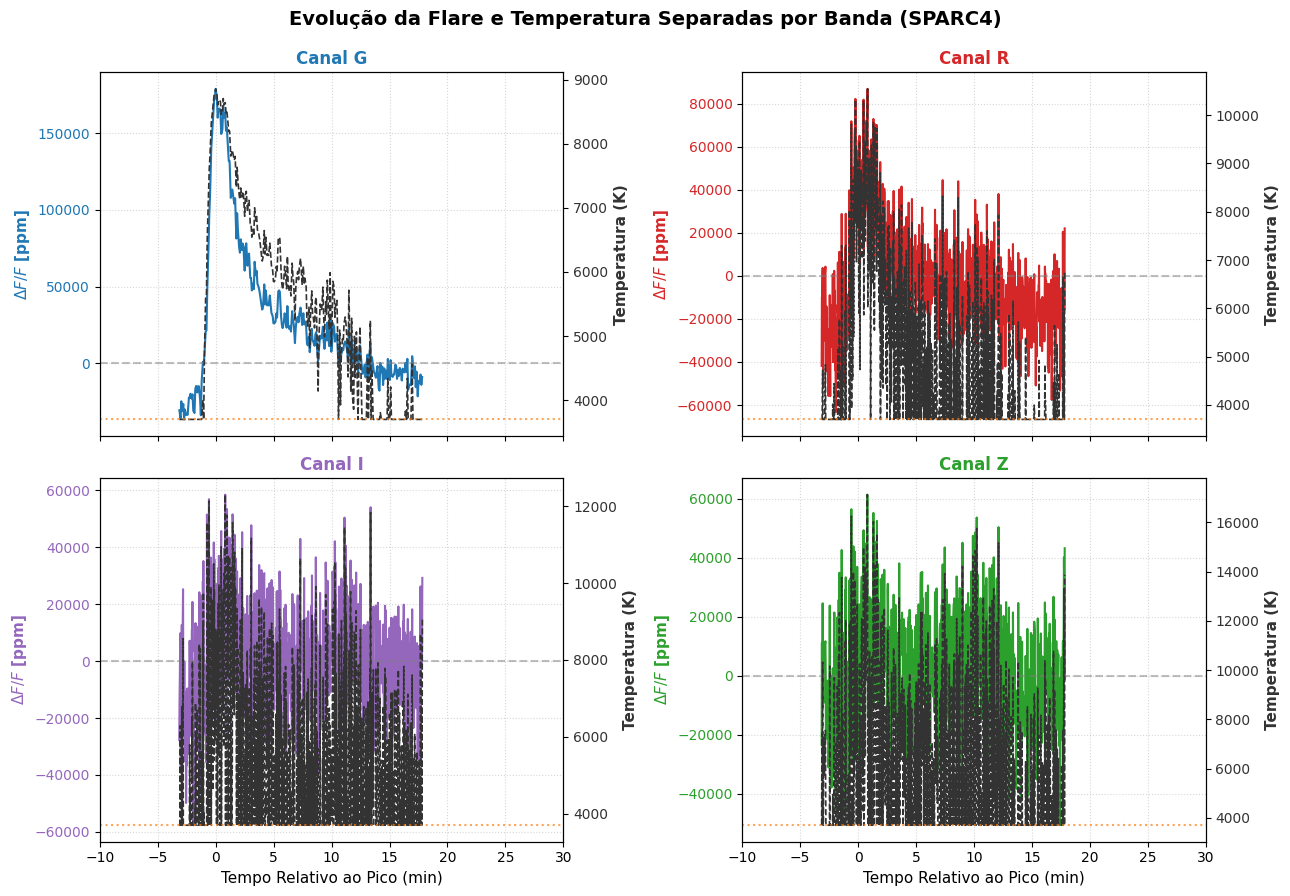

In [27]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np

# Cores padronizadas para cada canal
cores = {
    'g': '#1f77b4',  # Azul
    'r': '#d62728',  # Vermelho
    'i': '#9467bd',  # Roxo
    'z': '#2ca02c'   # Verde
}

# Criar grade 2x2 de subplots
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True)
axes = axes.flatten()

# Tempo de referência do pico (usando o canal g)
t_pico = flare['g']["t_min"][np.argmax(flare['g']["razao"])]

for idx, k in enumerate(canais):
    ax1 = axes[idx]
    
    # Tempo relativo ao pico em minutos
    t_rel = np.array(flare[k]["t_min"]) - t_pico
    amp_ppm = a_t[k] * 1e6
    T_k = T_flare_dict[k]
    
    # --- EIXO DA ESQUERDA: AMPLITUDE DA FLARE (ppm) ---
    color_amp = cores[k]
    ax1.plot(t_rel, amp_ppm, color=color_amp, lw=1.5, label=f'Amplitude ({k})')
    ax1.set_ylabel(r'$\Delta F / F$ [ppm]', color=color_amp, fontsize=11, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_amp)
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax1.grid(True, linestyle=':', alpha=0.5)
    
    # --- EIXO DA DIREITA: TEMPERATURA DERIVADA (K) ---
    ax2 = ax1.twinx()
    color_temp = '#333333'  # Cinza escuro para contraste
    ax2.plot(t_rel, T_k, color=color_temp, lw=1.2, linestyle='--', label=r'$T_{\mathrm{flare}}$')
    ax2.set_ylabel('Temperatura (K)', color=color_temp, fontsize=11, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_temp)
    ax2.axhline(Teff, color='tab:orange', linestyle=':', alpha=0.7, label=f'Teff ({Teff} K)')
    
    # Título do painel individual
    ax1.set_title(f"Canal {k.upper()}", fontsize=12, fontweight='bold', color=cores[k])
    ax1.set_xlim(-10, 30)  # Ajuste o intervalo de tempo conforme necessário
    
    # Rótulo do eixo X nos painéis inferiores
    if idx >= 2:
        ax1.set_xlabel("Tempo Relativo ao Pico (min)", fontsize=11)

plt.suptitle("Evolução da Flare e Temperatura Separadas por Banda (SPARC4)", fontsize=14, fontweight='bold', y=0.99)
plt.tight_layout()
plt.show()